# UCI CDE Python for Data Analysis  
## AI for Data Analysts with ChatGPT — Complete Instructor Lab

**Case:** BrightMart Retail Analytics  
**Length:** One class session  
**Audience:** Instructor version with sample answers, prompts, and verification notes

This notebook teaches students how to use AI as an assistant for:
1. Explaining Python errors
2. Writing pandas code
3. Reviewing generated code
4. Cleaning messy business data
5. Creating visualizations
6. Writing executive summaries
7. Testing AI limitations

> Instructor reminder: AI is a productivity assistant, not an authority. Students must verify every result.

## How to Use This Notebook

This instructor version contains:
- Demonstration prompts
- Student exercises
- Instructor solution code
- Verification checkpoints
- Discussion questions

For a student version, remove or hide the instructor solution cells.

## Learning Objectives

By the end of this lab, students should be able to:
- Use AI to explain Python and pandas errors.
- Write better prompts for data analysis tasks.
- Review AI-generated code for correctness.
- Verify AI-generated results using manual checks.
- Convert technical findings into executive recommendations.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Part 0 — Load BrightMart Data

In [18]:
from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis'
DATA_DIR = f'{BASE_DIR}/05_Datasets'
ASSIGNMENTS_DIR = f'{BASE_DIR}/04_Assignments'
OUTPUTS_DIR = f'{BASE_DIR}/04_Assignments/Outputs'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/UCI/UCI_427.62_Python_for_Data_Analysis/07_Capstone_Project/UCI_CDE_Capstone_Package1B/BrightMart_Retail_Dataset.csv")
df_raw.head()

,OrderID,OrderDate,Region,Category,CustomerSegment,Sales,Discount,Profit,Quantity
0,100000,2025-06-15,West,Technology,Consumer,"4,740.37",0.15,710.59,2
1,100001,2025-08-11,South,Office Supplies,Consumer,"2,102.50",0.05,-121.23,10
2,100002,2025-10-27,East,Office Supplies,Consumer,"1,995.47",0.05,-152.93,2
3,100003,2025-10-25,West,Furniture,Corporate,"2,864.60",0.05,181.80,10
4,100004,2025-08-21,East,Furniture,Corporate,"1,820.68",0.05,445.91,10


In [20]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
df_raw.info()

Rows: 3535
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3535 entries, 0 to 3534
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          3535 non-null   int64  
 1   OrderDate        3535 non-null   object 
 2   Region           3513 non-null   object 
 3   Category         3535 non-null   object 
 4   CustomerSegment  3535 non-null   object 
 5   Sales            3535 non-null   float64
 6   Discount         3535 non-null   float64
 7   Profit           3535 non-null   float64
 8   Quantity         3535 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 248.7+ KB


## Part 1 — Explaining Python Errors with AI

Students often copy an error message into ChatGPT. This is useful, but the prompt should include:
- the goal
- the code
- the full error message
- the dataset column names when relevant
- a request for explanation, not just a fix

### Demo Prompt: KeyError

**Prompt to use with ChatGPT:**

> I am using pandas in Jupyter. I want to calculate total sales by region.  
> My dataframe columns are shown below. I wrote this code:  
> `df.groupby("region")["Sales"].sum()`  
> I received a KeyError: 'region'.  
> Explain the error in beginner-friendly language and show the corrected code.

In [21]:
# Intentional error for demonstration:
# df_raw.groupby("region")["Sales"].sum()

print(df_raw.columns.tolist())

['OrderID', 'OrderDate', 'Region', 'Category', 'CustomerSegment', 'Sales', 'Discount', 'Profit', 'Quantity']


In [22]:
# Corrected solution
df_raw.groupby("Region")["Sales"].sum()

,Sales
Region,
Central,"2,406,377.69"
East,"2,491,995.07"
South,"2,376,625.83"
West,"2,579,725.29"
west,"156,208.11"


### Instructor Explanation

The error happens because pandas column names are case-sensitive.  
The dataset contains `Region`, not `region`.

**Verification:** Always print `df.columns.tolist()` before assuming column names.

### Student Exercise 1 — Explain a ValueError

Ask AI to explain why mixed date formats may cause problems.

Suggested prompt:

> I have an OrderDate column with mixed formats such as `2025-01-15` and `01/15/25`.  
> I want to convert it to datetime using pandas. What can go wrong, and how should I verify the result?

In [23]:
# Instructor solution
dates = pd.to_datetime(df_raw["OrderDate"], errors="coerce")
print("Invalid dates:", dates.isna().sum())
dates.head()

Invalid dates: 32


,OrderDate
0,2025-06-15
1,2025-08-11
2,2025-10-27
3,2025-10-25
4,2025-08-21


## Part 2 — AI-Assisted pandas Programming

AI can help generate pandas code, but the analyst must verify:
- Does the code answer the actual business question?
- Are columns correct?
- Are dates parsed correctly?
- Are aggregations at the right level?

### Demo Prompt: Calculate Monthly Revenue

> Write pandas code to calculate monthly revenue from a dataframe named df_raw.  
> The dataframe has OrderDate and Sales columns.  
> Convert dates safely, group by month, sort chronologically, and return a dataframe.

In [24]:
# Instructor solution
df = df_raw.copy()
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df["OrderMonth"] = df["OrderDate"].dt.to_period("M").astype(str)

monthly_revenue = (
    df.groupby("OrderMonth", as_index=False)["Sales"]
      .sum()
      .sort_values("OrderMonth")
)

monthly_revenue.head()

,OrderMonth,Sales
0,2025-01,"833,921.57"
1,2025-02,"978,054.78"
2,2025-03,"737,339.48"
3,2025-04,"799,236.28"
4,2025-05,"700,164.81"


### Verification Checkpoint

Students should verify:
- Number of months is reasonable.
- Sales total in grouped result equals original total.

In [25]:
print("Original sales total:", round(df["Sales"].sum(), 2))
print("Grouped sales total:", round(monthly_revenue["Sales"].sum(), 2))
print("Month count:", monthly_revenue["OrderMonth"].nunique())

Original sales total: 10063685.83
Grouped sales total: 10063685.83
Month count: 13


### Student Exercise 2 — Group by Region

Prompt AI to generate code for total sales and profit by region.  
Then verify that total sales and total profit match the original dataset.

In [26]:
# Instructor solution
region_summary = (
    df.groupby("Region", dropna=False)
      .agg(
          Orders=("OrderID", "count"),
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          AvgDiscount=("Discount", "mean")
      )
      .reset_index()
      .sort_values("Profit", ascending=False)
)

region_summary

,Region,Orders,Sales,Profit,AvgDiscount
1,East,849,"2,491,995.07","201,298.65",0.14
3,West,874,"2,579,725.29","186,630.79",0.13
2,South,889,"2,376,625.83","170,982.05",0.13
0,Central,836,"2,406,377.69","165,697.65",0.13
4,west,65,"156,208.11","9,119.85",0.15
5,NaN,22,"52,753.84","4,359.99",0.11


In [27]:
# Verification
print(round(region_summary["Sales"].sum(), 2), round(df["Sales"].sum(), 2))
print(round(region_summary["Profit"].sum(), 2), round(df["Profit"].sum(), 2))

10063685.83 10063685.83
738088.98 738088.98


## Part 3 — Reviewing AI-Generated Code

Students should learn to critique AI output rather than accept it blindly.

### Code Review Checklist

Ask:
1. Does the code run?
2. Are the column names correct?
3. Is the business question answered?
4. Are missing values handled?
5. Are dates handled properly?
6. Is the output easy to interpret?
7. Would an executive understand the result?

In [28]:
# Example AI-generated code that is incomplete:
# df.groupby("Region").sum()

# Better version:
region_kpi = (
    df.groupby("Region", dropna=False)
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("OrderID", "count"),
          AvgOrderValue=("Sales", "mean")
      )
      .assign(ProfitMargin=lambda x: x["Profit"] / x["Sales"])
      .sort_values("Profit", ascending=False)
)

region_kpi

,Sales,Profit,Orders,AvgOrderValue,ProfitMargin
Region,,,,,
East,"2,491,995.07","201,298.65",849,"2,935.21",0.08
West,"2,579,725.29","186,630.79",874,"2,951.63",0.07
South,"2,376,625.83","170,982.05",889,"2,673.37",0.07
Central,"2,406,377.69","165,697.65",836,"2,878.44",0.07
west,"156,208.11","9,119.85",65,"2,403.20",0.06
NaN,"52,753.84","4,359.99",22,"2,397.90",0.08


### Student Exercise 3 — Review AI Code

Give students this weak code:

```python
df.groupby("Category").sum()
```

Ask them to improve it for an executive audience.

In [29]:
# Instructor solution
category_kpi = (
    df.groupby("Category")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum"),
          Orders=("OrderID", "count"),
          AvgDiscount=("Discount", "mean")
      )
      .assign(ProfitMargin=lambda x: x["Profit"] / x["Sales"])
      .sort_values("Profit", ascending=False)
)

category_kpi

,Sales,Profit,Orders,AvgDiscount,ProfitMargin
Category,,,,,
Office Supplies,"3,534,425.29","250,737.92",1185,0.13,0.07
Furniture,"3,262,111.93","249,788.64",1164,0.13,0.08
Technology,"3,267,148.61","237,562.42",1186,0.13,0.07


## Part 4 — AI for Data Cleaning

AI can suggest cleaning steps, but students must inspect the dataset and justify each cleaning decision.

### Demo Prompt: Clean This Dataset

> I have a retail sales dataset with OrderDate, Region, Category, Sales, Profit, Discount, and Quantity.  
> Suggest pandas data-cleaning steps for duplicates, missing values, inconsistent region names, mixed date formats, and outliers.  
> Provide code and explain how to verify each step.

In [30]:
clean_df = df_raw.copy()

before_rows = len(clean_df)
clean_df = clean_df.drop_duplicates()
after_dedup_rows = len(clean_df)

clean_df["Region"] = clean_df["Region"].replace("", np.nan)
clean_df["Region"] = clean_df["Region"].astype("string").str.strip().str.title()
clean_df["Category"] = clean_df["Category"].astype("string").str.strip().str.title()
clean_df["CustomerSegment"] = clean_df["CustomerSegment"].astype("string").str.strip().str.title()

clean_df["OrderDate"] = pd.to_datetime(clean_df["OrderDate"], errors="coerce")
clean_df["OrderMonth"] = clean_df["OrderDate"].dt.to_period("M").astype(str)
clean_df["ProfitMargin"] = clean_df["Profit"] / clean_df["Sales"]

q1 = clean_df["Sales"].quantile(0.25)
q3 = clean_df["Sales"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
clean_df["SalesOutlierFlag"] = clean_df["Sales"] > upper_bound

print("Rows before:", before_rows)
print("Rows after duplicate removal:", after_dedup_rows)
print("Duplicate rows removed:", before_rows - after_dedup_rows)
print("Sales outliers:", clean_df["SalesOutlierFlag"].sum())

Rows before: 3535
Rows after duplicate removal: 3500
Duplicate rows removed: 35
Sales outliers: 26


In [31]:
pd.DataFrame({
    "missing_count": clean_df.isna().sum(),
    "missing_percent": (clean_df.isna().mean() * 100).round(2)
})

,missing_count,missing_percent
OrderID,0,0.00
OrderDate,32,0.91
Region,22,0.63
Category,0,0.00
CustomerSegment,0,0.00
Sales,0,0.00
Discount,0,0.00
Profit,0,0.00
Quantity,0,0.00
OrderMonth,0,0.00


### Student Exercise 4 — Cleaning Verification

Students should write 3 verification checks after cleaning.

Examples:
- Check duplicates.
- Check standardized region values.
- Check invalid dates.

In [32]:
# Instructor solution
print("Duplicates remaining:", clean_df.duplicated().sum())
print("Region values:", clean_df["Region"].value_counts(dropna=False).to_dict())
print("Invalid dates:", clean_df["OrderDate"].isna().sum())

Duplicates remaining: 0
Region values: {'West': 928, 'South': 878, 'East': 842, 'Central': 830, <NA>: 22}
Invalid dates: 32


## Part 5 — AI for Visualization

AI may suggest charts, but the analyst must choose the chart that best fits the business question.

### Demo Prompt: Best Visualization

> I need to show total sales by product category to executives.  
> What chart type should I use and why?  
> Then write matplotlib code using a dataframe named clean_df.

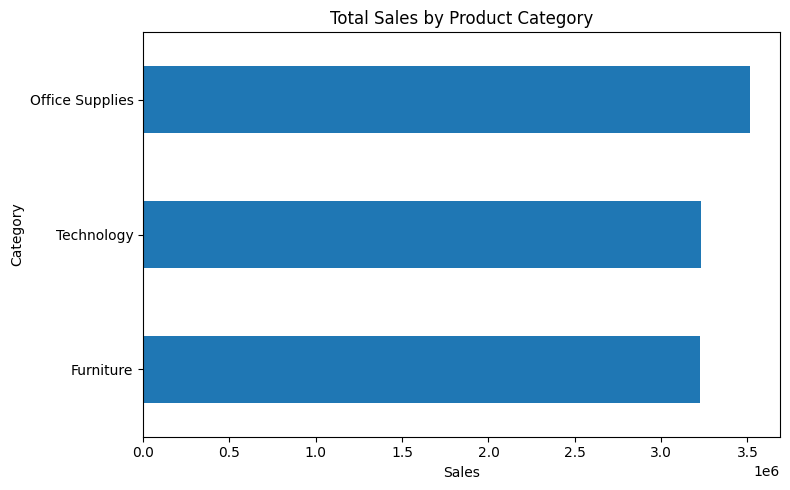

In [33]:
category_sales = clean_df.groupby("Category")["Sales"].sum().sort_values()

category_sales.plot(kind="barh", figsize=(8,5))
plt.title("Total Sales by Product Category")
plt.xlabel("Sales")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Student Exercise 5 — Sales vs Profit

Ask AI for a visualization comparing sales and profit.  
Then decide whether a scatter plot, grouped bar chart, or line chart is most appropriate.

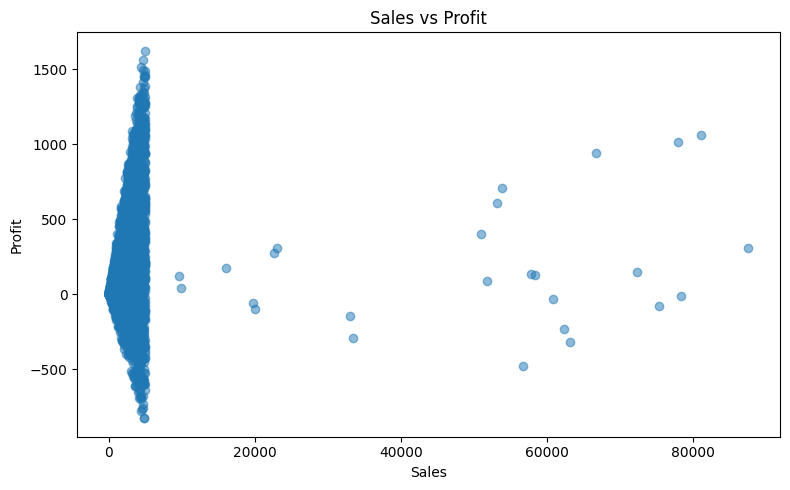

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(clean_df["Sales"], clean_df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Instructor Note

Scatter plots are useful for relationship questions.  
Bar charts are better for category comparison.  
Line charts are better for time trends.

## Part 6 — AI for Executive Report Generation

AI can help draft a summary, but students must edit for:
- accuracy
- evidence
- specificity
- business relevance
- tone

### Demo Prompt: Executive Summary

> Based on this analysis summary, draft a 150-word executive summary for BrightMart leadership:  
> Sales and profit vary by region and category. Higher discounts appear related to lower profit margins.  
> The dataset contained duplicates, inconsistent region names, mixed date formats, and outliers.  
> Recommend discount review, margin-focused KPIs, and data governance improvements.

In [35]:
executive_summary = '''
BrightMart should shift from revenue-only reporting to profitability-focused management.
The analysis shows that sales performance varies by region and category, while higher discount
levels may place pressure on profit margins. Data quality issues, including duplicate rows,
inconsistent region names, mixed date formats, and outliers, should be addressed before
executive reporting. Management should review discount approval practices, track profit margin
as a core KPI, prioritize higher-value customer segments, and implement a repeatable Python
reporting workflow.
'''
print(executive_summary)


BrightMart should shift from revenue-only reporting to profitability-focused management.
The analysis shows that sales performance varies by region and category, while higher discount
levels may place pressure on profit margins. Data quality issues, including duplicate rows,
inconsistent region names, mixed date formats, and outliers, should be addressed before
executive reporting. Management should review discount approval practices, track profit margin
as a core KPI, prioritize higher-value customer segments, and implement a repeatable Python
reporting workflow.



### Student Exercise 6 — Improve the AI Summary

Students should improve an AI-generated paragraph by adding:
- one specific finding
- one recommendation
- one limitation

In [36]:
# Instructor example improvement
improved_summary = '''
BrightMart should review discount policy and focus on profitable growth rather than sales growth alone.
After cleaning duplicate records and standardizing key fields, the analysis found that profitability differs
by region, category, and customer segment. Higher discount bands should be reviewed because they may
increase the risk of low-margin or negative-profit orders. The analysis is limited by missing region values
and potential sales outliers, so management should strengthen data validation before using the results in
formal reporting.
'''
print(improved_summary)


BrightMart should review discount policy and focus on profitable growth rather than sales growth alone.
After cleaning duplicate records and standardizing key fields, the analysis found that profitability differs
by region, category, and customer segment. Higher discount bands should be reviewed because they may
increase the risk of low-margin or negative-profit orders. The analysis is limited by missing region values
and potential sales outliers, so management should strengthen data validation before using the results in
formal reporting.



## Part 7 — AI Limitations and Verification

Students should intentionally test AI limitations.

### Bad Prompt Example

> Analyze my data and tell me what is wrong.

Why it is weak:
- no dataset context
- no business goal
- no column names
- no expected output
- no verification request

### Better Prompt Example

> I am analyzing a retail dataset with OrderDate, Region, Category, Sales, Profit, Discount, and Quantity.  
> My business goal is to identify why profit is inconsistent even when sales are increasing.  
> Please suggest pandas analyses, visualization ideas, and verification checks.  
> Do not invent results. Ask me for outputs if needed.

In [37]:
verification_checklist = [
    "Run the code.",
    "Check column names.",
    "Compare grouped totals to raw totals.",
    "Validate date parsing.",
    "Inspect missing values.",
    "Question unexpected results.",
    "Explain final conclusions in your own words."
]

for item in verification_checklist:
    print("✓", item)

✓ Run the code.
✓ Check column names.
✓ Compare grouped totals to raw totals.
✓ Validate date parsing.
✓ Inspect missing values.
✓ Question unexpected results.
✓ Explain final conclusions in your own words.


## Final Lab Exercise — BrightMart AI-Assisted Workflow

Students complete the following in one notebook:
1. Load data.
2. Ask AI to explain one error.
3. Ask AI to generate pandas code.
4. Review and improve AI code.
5. Clean the dataset.
6. Create two visualizations.
7. Write an executive summary.
8. Submit an AI prompt log.

In [38]:
# Final instructor reference workflow
final_region = (
    clean_df.groupby("Region", dropna=False)
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("OrderID","count"))
      .assign(ProfitMargin=lambda x: x["Profit"] / x["Sales"])
      .sort_values("Profit", ascending=False)
)

final_category = (
    clean_df.groupby("Category")
      .agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Orders=("OrderID","count"))
      .assign(ProfitMargin=lambda x: x["Profit"] / x["Sales"])
      .sort_values("Profit", ascending=False)
)

display(final_region)
display(final_category)

,Sales,Profit,Orders,ProfitMargin
Region,,,,
East,"2,464,805.72","199,985.19",842,0.08
West,"2,710,886.88","192,626.48",928,0.07
South,"2,345,129.23","169,320.69",878,0.07
Central,"2,393,426.52","164,467.20",830,0.07
<NA>,"52,753.84","4,359.99",22,0.08


,Sales,Profit,Orders,ProfitMargin
Category,,,,
Furniture,"3,223,594.40","248,927.09",1152,0.08
Office Supplies,"3,512,944.53","248,847.96",1175,0.07
Technology,"3,230,463.26","232,984.50",1173,0.07


## Instructor Answer Key Summary

A strong student submission should show:
- At least one documented AI prompt for debugging.
- Correct pandas code for grouping and summarizing.
- Evidence of verification.
- Clear cleaning decisions.
- At least two charts with titles and labels.
- Executive summary that does not invent unsupported facts.
- Reflection on AI strengths and limitations.

## AI Prompt Log Template

Students should record:

| Prompt # | Task | Prompt Used | AI Output Summary | Verification Step | What I Changed |
|---|---|---|---|---|---|
| 1 | Debugging | ... | ... | ... | ... |
| 2 | pandas | ... | ... | ... | ... |
| 3 | Executive summary | ... | ... | ... | ... |

## Closing Discussion

Ask students:
1. Where did AI help most?
2. Where did AI require correction?
3. What should never be pasted into an AI tool?
4. How should analysts document AI assistance?
5. How does AI change—but not replace—the analyst role?